# Audio Deepfake Detector - ODSS CNN v1
Dataset assumption used here:
- `natural/` = real human voice, label `0`
- `fastpitch-hifigan/` and `vits/` = synthetic voice, label `1`

Model approach: convert each audio clip to a fixed-size log-Mel spectrogram, then train a small CNN classifier.

## 2. Configuration

Download ODSS from Zenodo and unzip it. Set `ODSS_ROOT` to the folder that directly contains `natural`, `fastpitch-hifigan`, and `vits`.

In [ ]:
from pathlib import Path
import random
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

ODSS_ROOT = Path(r"C:\Users\gnane\dataset\odss")

SEED = 42
SAMPLE_RATE = 16000
CLIP_SECONDS = 3.0
N_MELS = 128
N_FFT = 1024
HOP_LENGTH = 256

BATCH_SIZE = 32
EPOCHS = 12
LEARNING_RATE = 3e-4
NUM_WORKERS = 0  


MAX_FILES_PER_CLASS = None

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

c:\Users\gnane\tam\tamenv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


## 3. Build the file index

This scans nested folders and creates labels from the top-level ODSS folders.

In [16]:
AUDIO_EXTENSIONS = {".wav", ".flac", ".mp3", ".ogg", ".m4a"}

def collect_audio_files(root: Path, label: int, class_name: str):
    files = []
    if not root.exists():
        print(f"Missing folder: {root}")
        return files
    for path in root.rglob("*"):
        if path.is_file() and path.suffix.lower() in AUDIO_EXTENSIONS:
            files.append({"path": str(path), "label": label, "class_name": class_name})
    return files

records = []
records += collect_audio_files(ODSS_ROOT / "natural", 0, "real")
records += collect_audio_files(ODSS_ROOT / "fastpitch-hifigan", 1, "fake")
records += collect_audio_files(ODSS_ROOT / "vits", 1, "fake")

df = pd.DataFrame(records)
if df.empty:
    raise FileNotFoundError(
        "No audio files found. Check ODSS_ROOT. It should contain natural/, fastpitch-hifigan/, and vits/."
    )

if MAX_FILES_PER_CLASS is not None:
    df = (
        df.groupby("label", group_keys=False)
        .apply(lambda x: x.sample(min(len(x), MAX_FILES_PER_CLASS), random_state=SEED))
        .reset_index(drop=True)
    )

print(df["class_name"].value_counts())
df.head()

class_name
fake    10627
real     6849
Name: count, dtype: int64


,path,label,class_name
0,C:\Users\gnane\dataset\odss\natural\hifi-tts\1...,0,real
1,C:\Users\gnane\dataset\odss\natural\hifi-tts\1...,0,real
2,C:\Users\gnane\dataset\odss\natural\hifi-tts\1...,0,real
3,C:\Users\gnane\dataset\odss\natural\hifi-tts\1...,0,real
4,C:\Users\gnane\dataset\odss\natural\hifi-tts\1...,0,real


## 4. Train / validation / test split

The split is stratified so both classes appear in each set.

In [17]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=SEED,
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=SEED,
)

print("Train:", len(train_df), train_df["class_name"].value_counts().to_dict())
print("Val:  ", len(val_df), val_df["class_name"].value_counts().to_dict())
print("Test: ", len(test_df), test_df["class_name"].value_counts().to_dict())

Train: 12233 {'fake': 7439, 'real': 4794}
Val:   2621 {'fake': 1594, 'real': 1027}
Test:  2622 {'fake': 1594, 'real': 1028}


## 5. Audio to log-Mel spectrogram

Each clip is loaded, converted to mono, resampled to 16 kHz, silence-trimmed, then padded/cropped to 3 seconds.

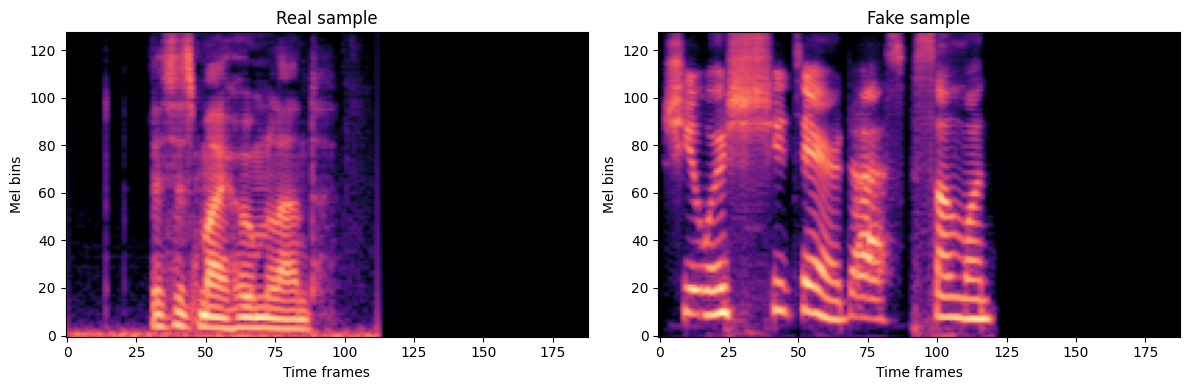

In [18]:
target_samples = int(SAMPLE_RATE * CLIP_SECONDS)

def audio_to_logmel(path):
    y, sr = librosa.load(path, sr=SAMPLE_RATE, mono=True)
    if len(y) == 0:
        y = np.zeros(target_samples, dtype=np.float32)
    else:
        y, _ = librosa.effects.trim(y, top_db=25)

    if len(y) < target_samples:
        y = np.pad(y, (0, target_samples - len(y)))
    else:
        start = 0
        if len(y) > target_samples:
            start = random.randint(0, len(y) - target_samples)
        y = y[start:start + target_samples]

    mel = librosa.feature.melspectrogram(
        y=y,
        sr=SAMPLE_RATE,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        n_mels=N_MELS,
        power=2.0,
    )
    logmel = librosa.power_to_db(mel, ref=np.max)
    logmel = (logmel - logmel.mean()) / (logmel.std() + 1e-6)
    return logmel.astype(np.float32)

sample_real = train_df[train_df.label == 0].iloc[0].path
sample_fake = train_df[train_df.label == 1].iloc[0].path

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, path, title in zip(axes, [sample_real, sample_fake], ["Real sample", "Fake sample"]):
    spec = audio_to_logmel(path)
    ax.imshow(spec, origin="lower", aspect="auto", cmap="magma")
    ax.set_title(title)
    ax.set_xlabel("Time frames")
    ax.set_ylabel("Mel bins")
plt.tight_layout()

## 6. PyTorch dataset and loaders

In [19]:
class ODSSAudioDataset(Dataset):
    def __init__(self, dataframe, augment=False):
        self.df = dataframe.reset_index(drop=True)
        self.augment = augment

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        spec = audio_to_logmel(row.path)

        if self.augment:
            spec = self.spec_augment(spec)

        x = torch.tensor(spec).unsqueeze(0)
        y = torch.tensor(row.label, dtype=torch.long)
        return x, y

    @staticmethod
    def spec_augment(spec):
        spec = spec.copy()
        if random.random() < 0.5:
            t = random.randint(8, 24)
            t0 = random.randint(0, max(0, spec.shape[1] - t))
            spec[:, t0:t0 + t] = 0
        if random.random() < 0.5:
            f = random.randint(8, 20)
            f0 = random.randint(0, max(0, spec.shape[0] - f))
            spec[f0:f0 + f, :] = 0
        return spec

train_loader = DataLoader(
    ODSSAudioDataset(train_df, augment=True),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=(device.type == "cuda"),
)
val_loader = DataLoader(
    ODSSAudioDataset(val_df, augment=False),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(device.type == "cuda"),
)
test_loader = DataLoader(
    ODSSAudioDataset(test_df, augment=False),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(device.type == "cuda"),
)

xb, yb = next(iter(train_loader))
print("Batch X:", xb.shape, "Batch y:", yb.shape)

Batch X: torch.Size([32, 1, 128, 188]) Batch y: torch.Size([32])


## 7. CNN model

This is a small CNN suitable for a first version. It is not a final research-grade architecture, but it is strong enough to learn spectrogram artifacts for a baseline.

In [20]:
class AudioDeepfakeCNN(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.35),
            nn.Linear(256, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(0.20),
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

model = AudioDeepfakeCNN().to(device)
total_params = sum(p.numel() for p in model.parameters())
print(model)
print(f"Parameters: {total_params:,}")

AudioDeepfakeCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=

## 8. Training helpers

In [21]:
def run_one_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    correct = 0
    total = 0
    all_probs = []
    all_labels = []

    for x, y in tqdm(loader, leave=False):
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        with torch.set_grad_enabled(is_train):
            logits = model(x)
            loss = criterion(logits, y)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        probs = torch.softmax(logits, dim=1)[:, 1]
        preds = torch.argmax(logits, dim=1)

        total_loss += loss.item() * x.size(0)
        correct += (preds == y).sum().item()
        total += x.size(0)
        all_probs.extend(probs.detach().cpu().numpy())
        all_labels.extend(y.detach().cpu().numpy())

    avg_loss = total_loss / total
    accuracy = correct / total
    try:
        auc = roc_auc_score(all_labels, all_probs)
    except ValueError:
        auc = float("nan")

    return avg_loss, accuracy, auc

class_counts = train_df["label"].value_counts().sort_index().values
class_weights = class_counts.sum() / (len(class_counts) * class_counts)
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=2)

print("Class counts [real, fake]:", class_counts)
print("Class weights:", class_weights.detach().cpu().numpy())

Class counts [real, fake]: [4794 7439]
Class weights: [1.2758657  0.82222074]


## 9. Train the model

In [22]:
history = []
best_val_auc = -1.0
checkpoint_path = Path("best_audio_deepfake_cnn_odss_v1.pt")

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc, train_auc = run_one_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc, val_auc = run_one_epoch(model, val_loader, criterion, optimizer=None)
    scheduler.step(val_auc)

    row = {
        "epoch": epoch,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "train_auc": train_auc,
        "val_loss": val_loss,
        "val_acc": val_acc,
        "val_auc": val_auc,
        "lr": optimizer.param_groups[0]["lr"],
    }
    history.append(row)
    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"train loss {train_loss:.4f} acc {train_acc:.4f} auc {train_auc:.4f} | "
        f"val loss {val_loss:.4f} acc {val_acc:.4f} auc {val_auc:.4f}"
    )

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        torch.save({
            "model_state_dict": model.state_dict(),
            "config": {
                "sample_rate": SAMPLE_RATE,
                "clip_seconds": CLIP_SECONDS,
                "n_mels": N_MELS,
                "n_fft": N_FFT,
                "hop_length": HOP_LENGTH,
            },
            "label_map": {0: "real", 1: "fake"},
            "val_auc": best_val_auc,
        }, checkpoint_path)
        print(f"Saved best checkpoint: {checkpoint_path} (val_auc={best_val_auc:.4f})")

history_df = pd.DataFrame(history)
history_df

Epoch 01/12 | train loss 0.4545 acc 0.7721 auc 0.8646 | val loss 0.3260 acc 0.8188 auc 0.9762
Saved best checkpoint: best_audio_deepfake_cnn_odss_v1.pt (val_auc=0.9762)


Epoch 02/12 | train loss 0.2425 acc 0.9013 auc 0.9640 | val loss 0.4704 acc 0.7325 auc 0.9897
Saved best checkpoint: best_audio_deepfake_cnn_odss_v1.pt (val_auc=0.9897)


Epoch 03/12 | train loss 0.1762 acc 0.9319 auc 0.9811 | val loss 0.6018 acc 0.7066 auc 0.9897


Epoch 04/12 | train loss 0.1376 acc 0.9460 auc 0.9883 | val loss 0.2927 acc 0.9008 auc 0.9935
Saved best checkpoint: best_audio_deepfake_cnn_odss_v1.pt (val_auc=0.9935)


Epoch 05/12 | train loss 0.1221 acc 0.9548 auc 0.9904 | val loss 0.2583 acc 0.8737 auc 0.9972
Saved best checkpoint: best_audio_deepfake_cnn_odss_v1.pt (val_auc=0.9972)


...

Epoch 09/12 | train loss 0.0844 acc 0.9674 auc 0.9955 | val loss 1.7213 acc 0.4895 auc 0.9963


Epoch 10/12 | train loss 0.0683 acc 0.9751 auc 0.9968 | val loss 0.4911 acc 0.8840 auc 0.9836


Epoch 11/12 | train loss 0.0445 acc 0.9826 auc 0.9988 | val loss 0.4252 acc 0.8012 auc 0.9992
Saved best checkpoint: best_audio_deepfake_cnn_odss_v1.pt (val_auc=0.9992)


Epoch 12/12 | train loss 0.0439 acc 0.9846 auc 0.9987 | val loss 0.1995 acc 0.9454 auc 0.9996
Saved best checkpoint: best_audio_deepfake_cnn_odss_v1.pt (val_auc=0.9996)


,epoch,train_loss,train_acc,train_auc,val_loss,val_acc,val_auc,lr
0,1,0.454484,0.772092,0.864630,0.325963,0.818771,0.976211,0.00030
1,2,0.242461,0.901251,0.964039,0.470441,0.732545,0.989682,0.00030
2,3,0.176192,0.931906,0.981090,0.601755,0.706601,0.989654,0.00030
3,4,0.137638,0.946048,0.988278,0.292675,0.900801,0.993492,0.00030
4,5,0.122112,0.954794,0.990446,0.258253,0.873712,0.997215,0.00030
5,6,0.109057,0.958146,0.992419,0.058152,0.976345,0.998681,0.00030
6,7,0.096182,0.962233,0.994247,0.284480,0.906143,0.998956,0.00030
7,8,0.083693,0.965176,0.995605,0.102017,0.963373,0.995746,0.00030
8,9,0.084439,0.967383,0.995545,1.721293,0.489508,0.996346,0.00030
9,10,0.068281,0.975067,0.996835,0.491136,0.884014,0.983576,0.00015


## 10. Plot training curves

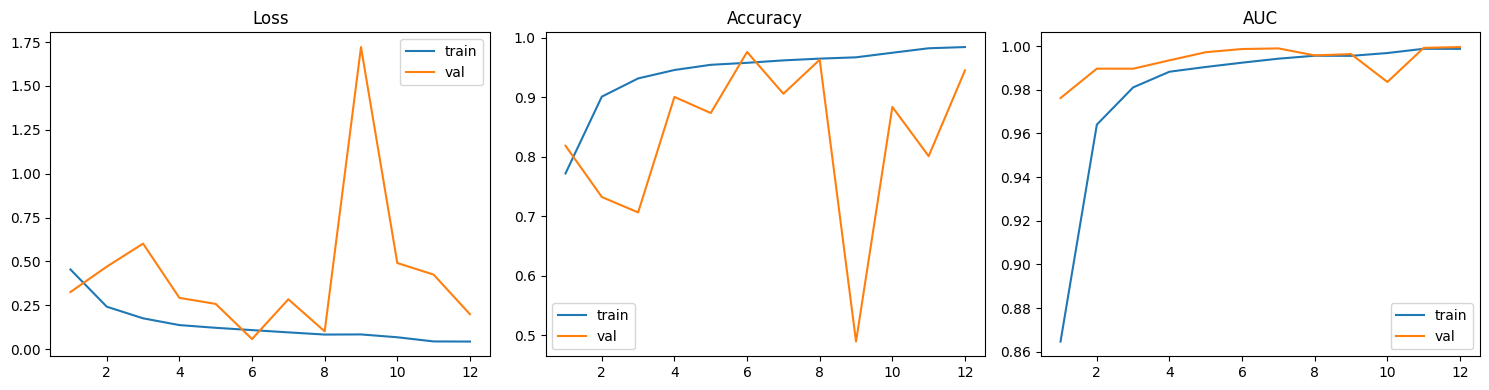

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history_df["epoch"], history_df["train_loss"], label="train")
axes[0].plot(history_df["epoch"], history_df["val_loss"], label="val")
axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(history_df["epoch"], history_df["train_acc"], label="train")
axes[1].plot(history_df["epoch"], history_df["val_acc"], label="val")
axes[1].set_title("Accuracy")
axes[1].legend()

axes[2].plot(history_df["epoch"], history_df["train_auc"], label="train")
axes[2].plot(history_df["epoch"], history_df["val_auc"], label="val")
axes[2].set_title("AUC")
axes[2].legend()

plt.tight_layout()

## 11. Test-set evaluation

C:\Users\gnane\AppData\Local\Temp\ipykernel_7820\4081923745.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location=device)

Test AUC: 0.9993067387918704
              precision    recall  f1-score   support

        real       1.00      0.87      0.93      1028
        fake       0.92      1.00      0.96      1594

    accuracy                           0.95      2622
   macro avg       0.96      0.93      0.94      2622
weighted avg       0.95      0.95      0.95      2622



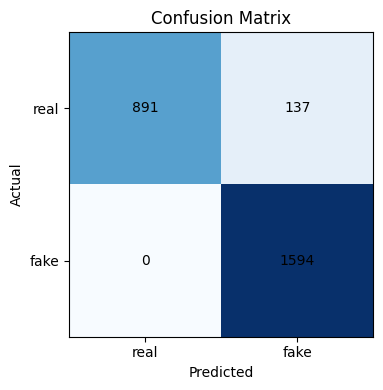

In [24]:
checkpoint = torch.load(checkpoint_path, map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

all_probs = []
all_preds = []
all_labels = []

with torch.no_grad():
    for x, y in tqdm(test_loader):
        x = x.to(device, non_blocking=True)
        logits = model(x)
        probs = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
        preds = np.argmax(logits.cpu().numpy(), axis=1)

        all_probs.extend(probs)
        all_preds.extend(preds)
        all_labels.extend(y.numpy())

print("Test AUC:", roc_auc_score(all_labels, all_probs))
print(classification_report(all_labels, all_preds, target_names=["real", "fake"]))

cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1], ["real", "fake"])
ax.set_yticks([0, 1], ["real", "fake"])
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix")
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center")
plt.tight_layout()

## 12. ROC curve

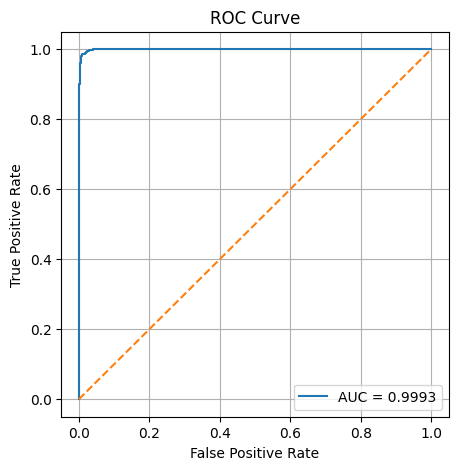

In [25]:
fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
auc_score = roc_auc_score(all_labels, all_probs)

plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

## 13. Predict one audio file

Use this after training. It returns `real` or `fake` plus confidence.

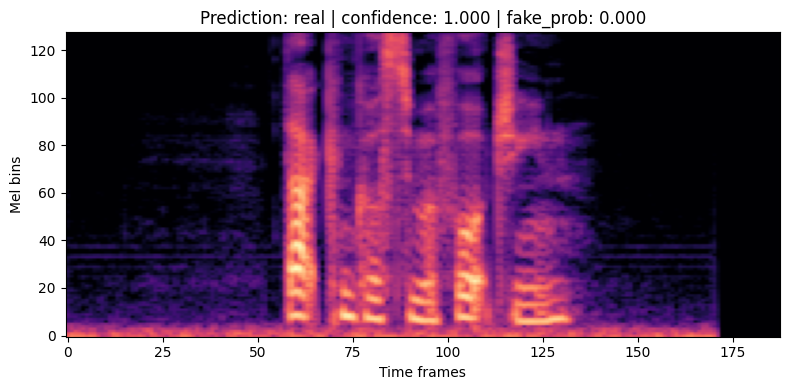

{'file': 'C:\\Users\\gnane\\dataset\\odss\\natural\\vctk\\p239\\p239_036.wav',
 'prediction': 'real',
 'confidence': 0.9996335536707193,
 'fake_probability': 0.00036644632928073406}

In [32]:
def predict_single_audio(audio_path, threshold=0.5, show_spectrogram=True):
    audio_path = Path(audio_path)
    if not audio_path.exists():
        raise FileNotFoundError(audio_path)

    spec = audio_to_logmel(str(audio_path))
    x = torch.tensor(spec).unsqueeze(0).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        logits = model(x)
        fake_probability = torch.softmax(logits, dim=1)[0, 1].item()

    label = "fake" if fake_probability >= threshold else "real"
    confidence = fake_probability if label == "fake" else 1.0 - fake_probability

    if show_spectrogram:
        plt.figure(figsize=(8, 4))
        plt.imshow(spec, origin="lower", aspect="auto", cmap="magma")
        plt.title(f"Prediction: {label} | confidence: {confidence:.3f} | fake_prob: {fake_probability:.3f}")
        plt.xlabel("Time frames")
        plt.ylabel("Mel bins")
        plt.tight_layout()
        plt.show()

    return {
        "file": str(audio_path),
        "prediction": label,
        "confidence": confidence,
        "fake_probability": fake_probability,
    }

# Example:
predict_single_audio(r"C:\Users\gnane\dataset\odss\natural\vctk\p239\p239_036.wav")